# Experiment No. 1
## Real-World Data Collection, Cleaning and Preprocessing using Python

**Aim:** To collect a real-world dataset from publicly available sources and perform data preprocessing by handling missing values, duplicate records, inconsistent formats, categorical variables, and outliers using Python.

**Dataset:** Titanic Survival Dataset (891 passengers, 12 columns)

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn (Google Colab)

## Step 1 & 2: Data collection and importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_style("whitegrid")

# Public copy of the Titanic dataset (same as Kaggle train.csv)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
# Alternative: upload Kaggle's train.csv and use pd.read_csv("train.csv")

## Step 3: Load and inspect the dataset

In [2]:
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


## Step 4: Handle missing values

          Missing  Percent
Age           177    19.87
Cabin         687    77.10
Embarked        2     0.22


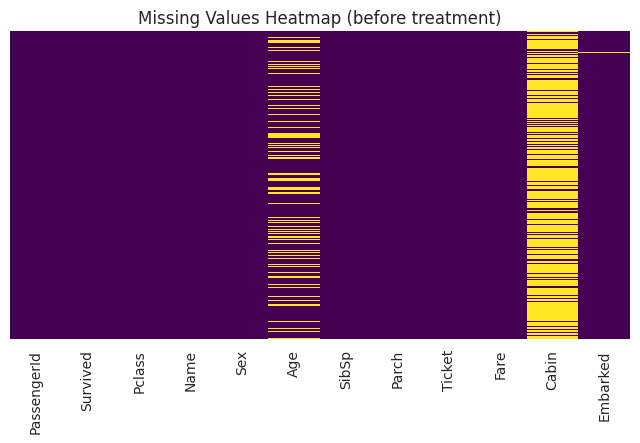

In [6]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing.Missing > 0])

plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap (before treatment)")
plt.show()

**Strategy:** Age (~20% missing) -> median; Embarked (2 missing) -> mode; Cabin (~77% missing) -> drop column.

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"])

print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Step 5: Detect and remove duplicates

In [8]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after:", df.duplicated().sum())
print("Shape now:", df.shape)

Duplicate rows before: 0
Duplicate rows after: 0
Shape now: (891, 11)


## Step 6: Standardize categories and encode them

In [9]:
# Clean text formatting
df["Sex"] = df["Sex"].str.strip().str.lower()
df["Embarked"] = df["Embarked"].str.strip().str.upper()

# Replace codes with full names
df["Embarked"] = df["Embarked"].map({"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"})
print(df["Sex"].unique(), df["Embarked"].unique())

['male' 'female'] ['Southampton' 'Cherbourg' 'Queenstown']


In [10]:
# Extract title from Name (before Name is dropped)
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
df["Title"] = df["Title"].replace(
    ["Lady", "the Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"], "Rare")
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
print(df["Title"].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [11]:
# Label encoding (binary column)
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# One-hot encoding (multi-category columns)
df = pd.get_dummies(df, columns=["Embarked", "Title"], dtype=int)

# Drop identifier-like columns not useful for analysis
df = df.drop(columns=["PassengerId", "Name", "Ticket"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Cherbourg,Embarked_Queenstown,Embarked_Southampton,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,0,0,1,0,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,1,0,0,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,0,0,1,0,1,0,0,0
3,1,1,1,35.0,1,0,53.1000,0,0,1,0,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,0,0,1,0,0,1,0,0


## Step 7: Detect and treat outliers (Box Plot + IQR)

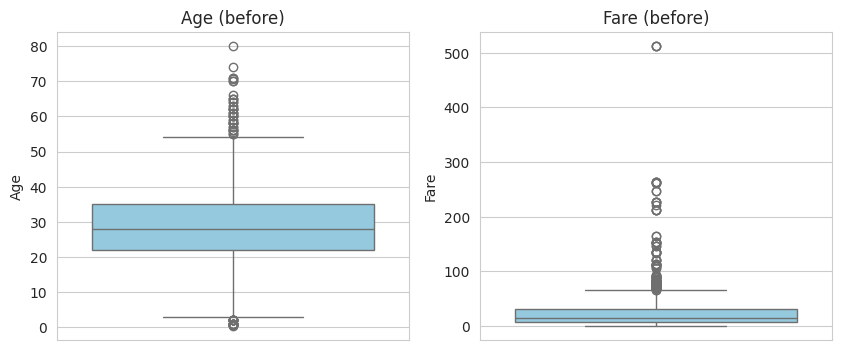

In [12]:
num_cols = ["Age", "Fare"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(f"{col} (before)")
plt.show()

In [13]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in num_cols:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: lower={low:.2f}, upper={high:.2f}, outliers={n_out}")

Age: lower=2.50, upper=54.50, outliers=66
Fare: lower=-26.72, upper=65.63, outliers=116


**Treatment:** values are capped (winsorized) at the IQR bounds so that no rows are lost.

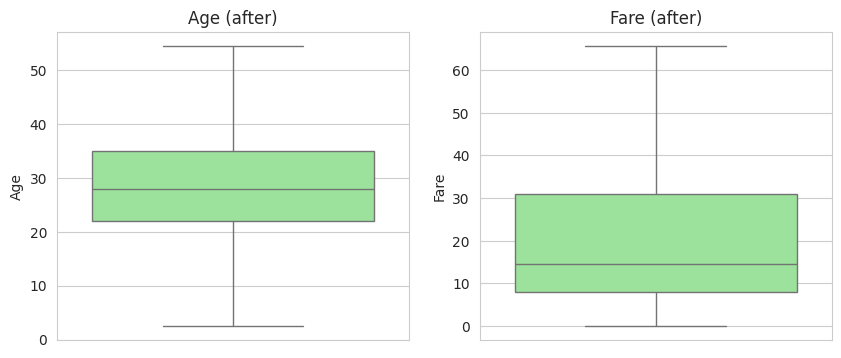

In [14]:
for col in num_cols:
    low, high = iqr_bounds(df[col])
    df[col] = df[col].clip(lower=low, upper=high)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightgreen")
    ax.set_title(f"{col} (after)")
plt.show()

## Step 8: Feature engineering

In [15]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                        labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"])
df["FareCategory"] = pd.qcut(df["Fare"].rank(method="first"), q=4,
                             labels=["Low", "Medium", "High", "VeryHigh"])

df = pd.get_dummies(df, columns=["AgeGroup", "FareCategory"], dtype=int)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Cherbourg,Embarked_Queenstown,Embarked_Southampton,...,IsAlone,AgeGroup_Child,AgeGroup_Teen,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_Senior,FareCategory_Low,FareCategory_Medium,FareCategory_High,FareCategory_VeryHigh
0,0,3,0,22.0,1,0,7.2500,0,0,1,...,0,0,0,1,0,0,1,0,0,0
1,1,1,1,38.0,1,0,65.6344,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,1,3,1,26.0,0,0,7.9250,0,0,1,...,1,0,0,1,0,0,0,1,0,0
3,1,1,1,35.0,1,0,53.1000,0,0,1,...,0,0,0,1,0,0,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1,...,1,0,0,1,0,0,0,1,0,0


## Step 9: Normalize / standardize numerical features

In [16]:
df[["Age_std", "Fare_std"]] = StandardScaler().fit_transform(df[["Age", "Fare"]])
df[["Age_norm", "Fare_norm"]] = MinMaxScaler().fit_transform(df[["Age", "Fare"]])

df[["Age", "Age_std", "Age_norm", "Fare", "Fare_std", "Fare_norm"]].describe().round(2)

,Age,Age_std,Age_norm,Fare,Fare_std,Fare_norm
count,891.00,891.00,891.00,891.00,891.00,891.00
mean,29.04,0.00,0.51,24.05,0.00,0.37
std,12.07,1.00,0.23,20.48,1.00,0.31
min,2.50,-2.20,0.00,0.00,-1.17,0.00
25%,22.00,-0.58,0.38,7.91,-0.79,0.12
50%,28.00,-0.09,0.49,14.45,-0.47,0.22
75%,35.00,0.49,0.62,31.00,0.34,0.47
max,54.50,2.11,1.00,65.63,2.03,1.00


## Step 10: Save the cleaned dataset

In [17]:
df.to_csv("titanic_cleaned.csv", index=False)
print("Final shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())

from google.colab import files
files.download("titanic_cleaned.csv")

Final shape: (891, 30)
Total missing values: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Observations

1. The raw dataset had 891 records and 12 columns, with missing values in Age, Cabin and Embarked.
2. Cabin had about 77% missing values, so the column was dropped. Age (about 20% missing) was filled with the median, and the 2 missing Embarked values with the mode.
3. No duplicate records were found in the dataset.
4. Sex was label encoded; Embarked and Title were one-hot encoded. Embarked codes (C, Q, S) were converted to full names.
5. Box plots and the IQR method showed outliers in Fare (a large number, due to a few very expensive tickets) and a few in Age. These were capped at the IQR bounds.
6. New features were created: FamilySize, IsAlone, Title, AgeGroup and FareCategory.
7. Age and Fare were standardized (mean 0, std 1) and normalized (range 0 to 1).
8. The final dataset has no missing values and all columns are numeric.

## Conclusion

The raw Titanic dataset was successfully cleaned and preprocessed using Python. Missing values were imputed or removed, duplicates were checked, categorical variables were encoded, outliers were treated using the IQR method, and numerical features were scaled. Feature engineering added new informative attributes. The resulting dataset is consistent, complete and ready for visualization and machine learning.

# Questions and Answers

### Q1. Why is data preprocessing considered one of the most important phases in data analytics?

Real-world data is incomplete, inconsistent, duplicated and noisy. Analysis or models built on such data give unreliable results ("garbage in, garbage out"). Preprocessing is important because it:
- improves data quality and accuracy, so conclusions can be trusted;
- converts raw data into a format algorithms can use (numeric, scaled, encoded);
- removes errors, duplicates and outliers that distort results;
- reduces noise and improves model performance and training speed;
- typically takes 60 to 80% of the time in an analytics project, because everything downstream depends on it.

### Q2. Explain different methods of handling missing values with suitable examples.

| Method | Description | Example |
|---|---|---|
| Deletion (row) | Remove records with missing values; suitable when few rows are affected | `df.dropna()` |
| Deletion (column) | Drop a feature with too many missing values | Titanic `Cabin` (~77% missing): `df.drop(columns=["Cabin"])` |
| Mean imputation | Fill with the average; for numeric, symmetric data | `df["Salary"].fillna(df["Salary"].mean())` |
| Median imputation | Fill with the middle value; for skewed data or data with outliers | Titanic `Age`: `df["Age"].fillna(df["Age"].median())` |
| Mode imputation | Fill with the most frequent value; for categorical data | Titanic `Embarked`: `fillna(df["Embarked"].mode()[0])` |
| Constant / flag value | Fill with a fixed value such as "Unknown" or 0 | `df["City"].fillna("Unknown")` |
| Forward / backward fill | Copy the previous or next value; for time-series data | `df.ffill()` |
| Model-based imputation | Predict missing values using other columns | KNN imputer, regression imputation |

### Q3. Differentiate between Label Encoding and One-Hot Encoding.

| Basis | Label Encoding | One-Hot Encoding |
|---|---|---|
| Working | Assigns each category an integer (0, 1, 2, ...) | Creates one binary (0/1) column per category |
| Number of columns | One column | One column per category |
| Example | Low=0, Medium=1, High=2 | Embarked -> Embarked_C, Embarked_Q, Embarked_S |
| Implied order | Introduces an artificial order between categories | No order is implied |
| Best for | Binary or ordinal data (Sex, Education level) | Nominal data with no order (City, Department) |
| Drawback | Models may wrongly treat 2 as "greater than" 1 | Increases dimensionality when there are many categories |

### Q4. What are outliers? How can they affect analytical results?

**Outliers** are data points that differ markedly from the rest of the observations, for example a Titanic fare of 512 when most fares are below 50, or an age of 200 entered by mistake. They may come from data-entry errors, measurement errors, or genuine extreme values.

**Effects on analysis:**
- They distort the mean and standard deviation, giving a misleading picture of the data.
- They skew regression lines and reduce model accuracy.
- They affect distance-based algorithms (KNN, K-Means) and scaling methods.
- They can lead to wrong conclusions and poor predictions.

**Detection and treatment:** box plots, the IQR method (below Q1 - 1.5 x IQR or above Q3 + 1.5 x IQR), and Z-score. They can be removed, capped (winsorized), or transformed (for example log transform).

### Q5. Explain the difference between normalization and standardization.

| Basis | Normalization (Min-Max scaling) | Standardization (Z-score scaling) |
|---|---|---|
| Formula | x' = (x - min) / (max - min) | z = (x - mean) / standard deviation |
| Resulting range | Fixed, usually 0 to 1 | No fixed range; mean = 0, std = 1 |
| Effect of outliers | Highly sensitive, since min and max are used | Less sensitive |
| Use when | Data is not Gaussian; algorithms such as KNN and neural networks | Data is roughly Gaussian; algorithms such as SVM, logistic regression, PCA |
| Python | `MinMaxScaler()` | `StandardScaler()` |

Example: ages 20, 30, 40 become 0, 0.5, 1 after normalization, and about -1.22, 0, 1.22 after standardization.

### Q6. Why should duplicate records be removed before analysis?

- Duplicates inflate the dataset size and give some records extra weight, which biases statistics such as counts, means and percentages.
- Models may over-learn repeated records and overfit.
- If duplicates end up in both the training and test sets, the test accuracy is falsely high (data leakage).
- They waste storage and processing time.
- They cause errors in reports, for example counting the same customer or employee twice.

In Pandas: `df.drop_duplicates()`.

### Q7. What is feature engineering? Give two practical examples.

**Feature engineering** is the process of creating new features, or transforming existing ones, using domain knowledge so that the data represents the problem better and model performance improves.

**Examples:**
1. **Titanic:** `FamilySize = SibSp + Parch + 1` combines two columns into one meaningful feature, and `Age` can be binned into an `AgeGroup` (Child, Teen, Adult, Senior).
2. **IBM HR:** `Income Category` (Low, Medium, High) from `MonthlyIncome`, or `TenureRatio = YearsAtCompany / TotalWorkingYears` to show how loyal an employee is.

### Q8. Which preprocessing techniques would you apply to the IBM HR Employee Attrition dataset and why?

| Technique | Application | Reason |
|---|---|---|
| Missing value check | Run `isnull().sum()`; impute if needed | This dataset is mostly complete, but it should always be verified |
| Remove duplicates | `drop_duplicates()` | Avoids biased results |
| Drop constant / useless columns | `EmployeeCount`, `StandardHours`, `Over18`, `EmployeeNumber` | They have the same value for everyone or are only identifiers, so they carry no information |
| Label encoding | `Attrition` (Yes/No), `Gender`, `OverTime` | Binary categories need to become 0/1 |
| One-hot encoding | `Department`, `JobRole`, `MaritalStatus`, `BusinessTravel`, `EducationField` | Nominal categories with no order |
| Outlier treatment (IQR) | `MonthlyIncome`, `YearsAtCompany`, `TotalWorkingYears` | These are right-skewed with extreme values |
| Scaling | Standardize or normalize `Age`, `MonthlyIncome`, `DistanceFromHome` | Features are on very different scales |
| Feature engineering | Income category, tenure ratio, age group | Captures patterns linked to attrition |
| Handle class imbalance | Use SMOTE or class weights | Only about 16% of employees have left, so the target is imbalanced |

### Q9. How does poor-quality data affect machine learning model performance?

- **Lower accuracy:** noise, errors and wrong labels lead the model to learn incorrect patterns.
- **Bias:** missing or unrepresentative data produces biased and unfair predictions.
- **Overfitting:** duplicates and outliers cause the model to memorize rather than generalize.
- **Misleading evaluation:** data leakage gives falsely high scores that fail in real use.
- **Training problems:** unscaled or unencoded data can slow down or break algorithms.
- **Poor decisions:** unreliable predictions lead to wrong business decisions and wasted cost.

### Q10. Name any three Python libraries commonly used for data preprocessing.

1. **Pandas:** data loading, cleaning, handling missing values and duplicates, transformation.
2. **NumPy:** numerical operations, arrays, handling `NaN` values.
3. **Scikit-learn:** scaling (`StandardScaler`, `MinMaxScaler`), encoding (`LabelEncoder`, `OneHotEncoder`), imputation (`SimpleImputer`), train-test split.

(Matplotlib and Seaborn are also used for visualizing missing values and outliers.)